In [1]:
pip install transformers torch pyarrow

  Using cached transformers-4.57.3-py3-none-any.whl.metadata (43 kB)
  Using cached torch-2.9.1-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (30 kB)
  Using cached filelock-3.20.2-py3-none-any.whl.metadata (2.1 kB)
  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
  Using cached regex-2025.11.3-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.8 kB)
  Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.9 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_runtime_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia

In [1]:
import pandas as pd
import numpy as np
import time
import datetime
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,random_split
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
from transformers import BertTokenizer,BertModel, get_linear_schedule_with_warmup
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_parquet("ssh_attacks.parquet")

mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df["Set_Fingerprint"])

''' 
dato che ogni sessione ha più di un intento contemporaneamente
abbiamo un problema di multi-label classification
quindi ci serve una rappresentazione numerica
per questo con binarizer trasformo ogni insieme in un vettore
di 0 e 1 per capire se un intento c'è nella sessione (1) oppure no (0)
'''

sentences = df["full_session"].tolist()


tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")


'''
per la tokenizzazione prima troviamo la max_len, poi 
usiamo la funzione encode come nella guida
'''






'\nper la tokenizzazione prima troviamo la max_len, poi \nusiamo la funzione encode come nella guida\n'

In [2]:
'''
max_len = 0

for sent in sentences:
   input_ids = tokenizer.encode(sent, add_special_tokens = True,max_length=512,truncation=True)
    max_len = max(max_len, len(input_ids))

print("Max sentence length found:", max_len)
MAX_LEN = min(max_len,64)
print("Using MAX_LEN =", MAX_LEN)
'''
MAX_LEN = 64

In [3]:
'''
tokenizzazione completa
'''

input_ids = []
attention_masks = []

for sent in sentences:
    encoded_dict = tokenizer.encode_plus(
        sent,
        add_special_tokens=True,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_tensors="pt"
    )

    input_ids.append(encoded_dict["input_ids"])
    attention_masks.append(encoded_dict["attention_mask"])


#conversione in tensori
input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(y, dtype=torch.float)

print("Esempio tokenizzato:")
print("Testo originale:", sentences[0][:200], "...")
print("Token IDs:", input_ids[0])
print("Attention mask:", attention_masks[0])


#training e validation split
dataset = TensorDataset(input_ids, attention_masks, labels)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"{train_size:,} training samples")
print(f"{val_size:,} validation samples")

#dataloader

batch_size = 32

train_dataloader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),
    batch_size=batch_size
)

validation_dataloader = DataLoader(
    val_dataset,
    sampler=SequentialSampler(val_dataset),
    batch_size=batch_size
)



Esempio tokenizzato:
Testo originale: enable ; system ; shell ; sh ; cat /proc/mounts ; /bin/busybox SAEMW ; cd /dev/shm ; cat .s || cp /bin/echo .s ; /bin/busybox SAEMW ; tftp ; wget ; /bin/busybox SAEMW ; dd bs=52 count=1 if=.s || cat . ...
Token IDs: tensor([  101,  9585,  1025,  2291,  1025,  5806,  1025, 14021,  1025,  4937,
         1013,  4013,  2278,  1013, 19363,  1025,  1013,  8026,  1013,  5697,
         8758,  7842,  6633,  2860,  1025,  3729,  1013, 16475,  1013, 14021,
         2213,  1025,  4937,  1012,  1055,  1064,  1064, 18133,  1013,  8026,
         1013,  9052,  1012,  1055,  1025,  1013,  8026,  1013,  5697,  8758,
         7842,  6633,  2860,  1025,  1056,  6199,  2361,  1025,  1059, 18150,
         1025,  1013,  8026,   102])
Attention mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
209,731 

In [10]:
'''
per il nostro problema non si può usare BertForSequenceClassification  
perchè usa CrossEntropyLoss, che non funziona per multi-label
per questo useremo BertModel + nn.Linear che è utile per multi-label
'''

bert = BertModel.from_pretrained(
   "bert-base-uncased",
    output_attentions=False,
    output_hidden_states=False 
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert.to(device)

for param in bert.parameters():
    param.requires_grad = False

##DOMANDA 1 ---> AGGIUNTA DI UN LAYER LINEARE FINALE
num_labels = y.shape[1]

#layer finale
classifier = nn.Linear(bert.config.hidden_size, num_labels).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = AdamW(
    classifier.parameters(),
    lr=2e-5,
    eps=1e-8 
)

epochs = 4

total_steps = len(train_dataloader) * epochs

scheduler = get_linear_schedule_with_warmup(optimizer, 
                                            num_warmup_steps=0, 
                                            num_training_steps=total_steps)



======== Epoch 1 / 4 ========
Training...
  Batch    40  of  6,555.    Elapsed: 0:00:26.
  Batch    80  of  6,555.    Elapsed: 0:00:51.
  Batch   120  of  6,555.    Elapsed: 0:01:16.
  Batch   160  of  6,555.    Elapsed: 0:01:40.
  Batch   200  of  6,555.    Elapsed: 0:02:00.
  Batch   240  of  6,555.    Elapsed: 0:02:19.
  Batch   280  of  6,555.    Elapsed: 0:02:44.
  Batch   320  of  6,555.    Elapsed: 0:03:08.
  Batch   360  of  6,555.    Elapsed: 0:03:32.
  Batch   400  of  6,555.    Elapsed: 0:03:55.
  Batch   440  of  6,555.    Elapsed: 0:04:19.
  Batch   480  of  6,555.    Elapsed: 0:04:41.
  Batch   520  of  6,555.    Elapsed: 0:05:06.
  Batch   560  of  6,555.    Elapsed: 0:05:30.
  Batch   600  of  6,555.    Elapsed: 0:05:52.
  Batch   640  of  6,555.    Elapsed: 0:06:14.
  Batch   680  of  6,555.    Elapsed: 0:06:38.
  Batch   720  of  6,555.    Elapsed: 0:07:03.
  Batch   760  of  6,555.    Elapsed: 0:07:29.
  Batch   800  of  6,555.    Elapsed: 0:07:54.
  Batch   840  of

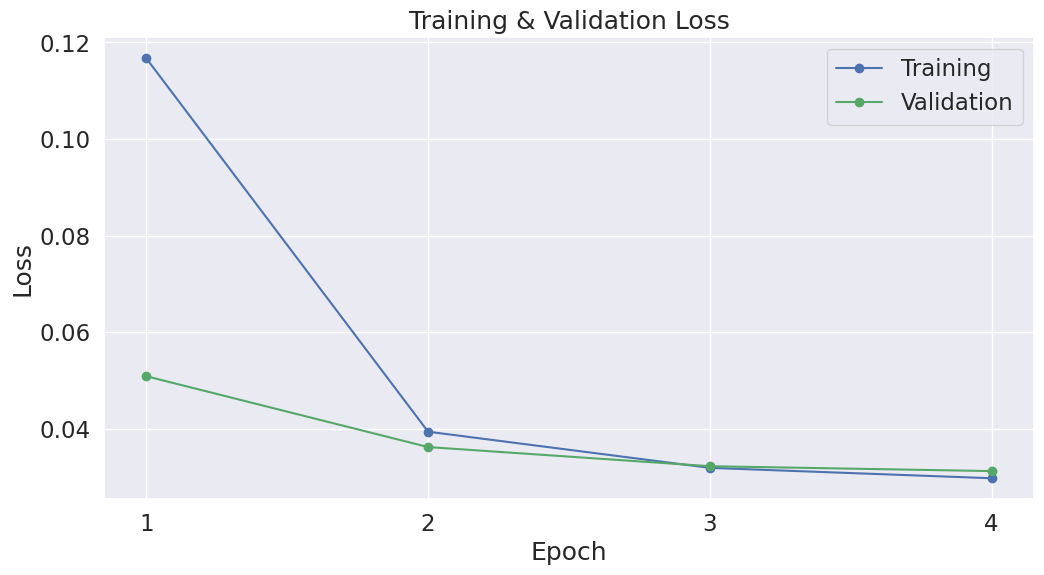

In [11]:
#training loop

#prima funzione per formattare il tempo 

def format_time(elapsed):
    elapsed_rounded = int(round(elapsed))
    return str(datetime.timedelta(seconds=elapsed_rounded))

training_stats = [] 
total_t0 = time.time()

for epoch_i in range(0, epochs):

    print("")
    print(f"======== Epoch {epoch_i+1} / {epochs} ========")
    print("Training...")

    t0 = time.time()
    total_train_loss = 0

    classifier.train()

    for step, batch in enumerate(train_dataloader):

        if step % 40 == 0 and not step == 0:
            elapsed = format_time(time.time() - t0)
            print(f"  Batch {step:>5,}  of  {len(train_dataloader):>5,}.    Elapsed: {elapsed}.")

        b_input_ids = batch[0].to(device)
        b_attn = batch[1].to(device)
        b_labels = batch[2].to(device)

        optimizer.zero_grad()

        # FORWARD PASS
        outputs = bert(input_ids=b_input_ids, attention_mask=b_attn)
        cls_emb = outputs.last_hidden_state[:, 0, :]
        logits = classifier(cls_emb)

        # CALCOLO LOSS
        loss = criterion(logits, b_labels)
        total_train_loss += loss.item()

        # BACKWARD PASS
        loss.backward()
        torch.nn.utils.clip_grad_norm_(classifier.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    training_time = format_time(time.time() - t0)

    print("")
    print(f"  Average training loss: {avg_train_loss:.2f}")
    print(f"  Training epoch took: {training_time}")

    # ========================================
    #               VALIDATION
    # ========================================
    print("")
    print("Running Validation...")

    t0 = time.time()
    classifier.eval()

    total_val_loss = 0

    with torch.no_grad():
        for batch in validation_dataloader:

            b_input_ids = batch[0].to(device)
            b_attn = batch[1].to(device)
            b_labels = batch[2].to(device)

            outputs = bert(input_ids=b_input_ids, attention_mask=b_attn)
            cls_emb = outputs.last_hidden_state[:, 0, :]
            logits = classifier(cls_emb)

            loss = criterion(logits, b_labels)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(validation_dataloader)
    validation_time = format_time(time.time() - t0)

    print(f"  Validation Loss: {avg_val_loss:.2f}")
    print(f"  Validation took: {validation_time}")

    training_stats.append({
        "epoch": epoch_i + 1,
        "Training Loss": avg_train_loss,
        "Valid. Loss": avg_val_loss,
        "Training Time": training_time,
        "Validation Time": validation_time
    })

print("")
print("Training complete!")
print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))


#creo il dataframe e plot delle learning curves

pd.set_option('display.precision', 2)

df_stats = pd.DataFrame(training_stats)
df_stats = df_stats.set_index('epoch')

df_stats

sns.set(style='darkgrid')
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

plt.plot(df_stats['Training Loss'], 'b-o', label="Training")
plt.plot(df_stats['Valid. Loss'], 'g-o', label="Validation")

plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.xticks(df_stats.index)

plt.show()



